In [3]:
# ---------------------------------------------------------------
# 1. LIBRARIES
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from xgboost import XGBRegressor, XGBClassifier

from sklearn.metrics import (mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score,
                              roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score,
                              confusion_matrix, classification_report)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 100


## 1. Load Data

In [4]:
import pandas as pd
# Construct the direct export URL for the Google Sheet
gsheet_id = '16TxEsQpPa60yuimnG_v2NRhUur9FcKXD'
gsheet_url = f'https://docs.google.com/spreadsheets/d/{gsheet_id}/export?format=xlsx'

df = pd.read_excel(gsheet_url, sheet_name='Sheet1')
df.columns = [c.strip().replace(' ', '_') for c in df.columns]
df = df.rename(columns={'Traiffic_Challan_Amount': 'Traffic_Challan_Amount'})   # fix source typo
print('Shape:', df.shape)
df.head()

Shape: (15000, 41)


,Agmt_Id,Cust_Age,Cust_Gender,Cust_Cibil_Score,Cust_Employment_Type,Cust_Net_Salary,Coborrower_Flag,App_Score_Risk,Agmt_Date,Seizure_Date,Sold_Date,Tenure,Cust_Net_IRR,Sold_Date_Month,Sold_Date_Year,Seizure_Date_Month,Seizure_Date_Year,Cust_Branch,Cust_Region,Cust_State,Pincode_Tier,RC_Availability,Registration_Flag,Asset_Disc_Flag,Asset_Alloy_Flag,Asset_Variant,Asset_Model,Asset_Fuel_Type,Asset_Cost_At_Disbursal,Loan_Amount,LTV,OS_Balance_At_Liquidation,Asset_Age_Months_At_Seizure,Months_Spent_In_Yard,Asset_Bodycondition,Asset_Tyrecondition,Asset_Generalcondition,Asset_Enginecondition,Asset_Accident_Flag,Traffic_Challan_Amount,Target_Sold_Amount_At_Liquidation
0,ASSET_1,29,F,-1,NREGI,30000,N,LOW RISK,2023-12-27,2025-05-23,2025-06-23,29,24.69,6,2025,5,2025,HYDERABAD I,AP,AP,02 Megapolis (B),N,REG,0,0,TVS XL 100 HD ITS,MOPEDS,Petrol,81000,68712,0.848296,46934.0,17.100000,1.033333,G,G,G,G,No,0,37000.0
1,ASSET_2,24,M,-1,NREGI,60000,N,LOW RISK,2025-11-20,2026-05-31,2026-07-29,23,26.90,7,2026,5,2026,TIRUPATHI,AP,AP,06 Semi-Urban,N,REG,1,0,RADEON DRUM,RADEON,Petrol,106800,90750,0.849719,85177.0,6.400000,1.966667,G,G,G,G,No,0,56000.0
2,ASSET_3,32,F,763,AGR,29500,N,LOW RISK,2024-05-16,2025-06-24,2025-08-25,23,27.23,8,2025,6,2025,VIJAYAWADA,AP,AP,06 Semi-Urban,N,REG,0,0,TVS XL 100 HD ITS,MOPEDS,Petrol,80650,73666,0.913404,51678.1,13.466667,2.066667,A,A,A,A,No,0,40500.0
3,ASSET_4,25,F,-1,NREGI,40000,N,MEDIUM RISK,2025-10-24,2026-04-30,2026-06-26,23,24.38,6,2026,4,2026,KARIMNAGAR,AP,AP,05 Urban,N,REG,0,0,TVS XL 100 WINNER ITS,MOPEDS,Petrol,82500,70840,0.858667,65874.0,6.266667,1.900000,A,A,A,A,No,0,49000.0
4,ASSET_5,59,F,653,SAL,45000,N,MEDIUM RISK,2024-09-20,2025-05-30,2025-07-24,23,33.23,7,2025,5,2025,KARIMNAGAR,AP,AP,06 Semi-Urban,N,REG,0,0,TVS XL 100 WINNER ITS,MOPEDS,Petrol,82500,72518,0.879006,66571.0,8.400000,1.833333,G,G,G,G,No,0,46000.0


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Agmt_Id                            15000 non-null  object        
 1   Cust_Age                           15000 non-null  int64         
 2   Cust_Gender                        15000 non-null  object        
 3   Cust_Cibil_Score                   15000 non-null  int64         
 4   Cust_Employment_Type               15000 non-null  object        
 5   Cust_Net_Salary                    15000 non-null  int64         
 6   Coborrower_Flag                    15000 non-null  object        
 7   App_Score_Risk                     15000 non-null  object        
 8   Agmt_Date                          15000 non-null  datetime64[ns]
 9   Seizure_Date                       15000 non-null  datetime64[ns]
 10  Sold_Date                         

## 2. Exploratory Data Analysis

Key checks: missing values, target distribution, sentinel/placeholder values, and relationships
between drivers (asset age, LTV, condition grades) and the liquidation amount.

In [6]:
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — dataset has no NaNs.')

# Cust_Cibil_Score uses -1 as a sentinel for "no bureau record" (new-to-credit / thin-file customers)
print('\nRecords with Cust_Cibil_Score <= 0 (no bureau hit):', (df['Cust_Cibil_Score'] <= 0).sum(),
      f"({(df['Cust_Cibil_Score'] <= 0).mean():.1%} of book)")


Columns with missing values:
None — dataset has no NaNs.

Records with Cust_Cibil_Score <= 0 (no bureau hit): 8850 (59.0% of book)


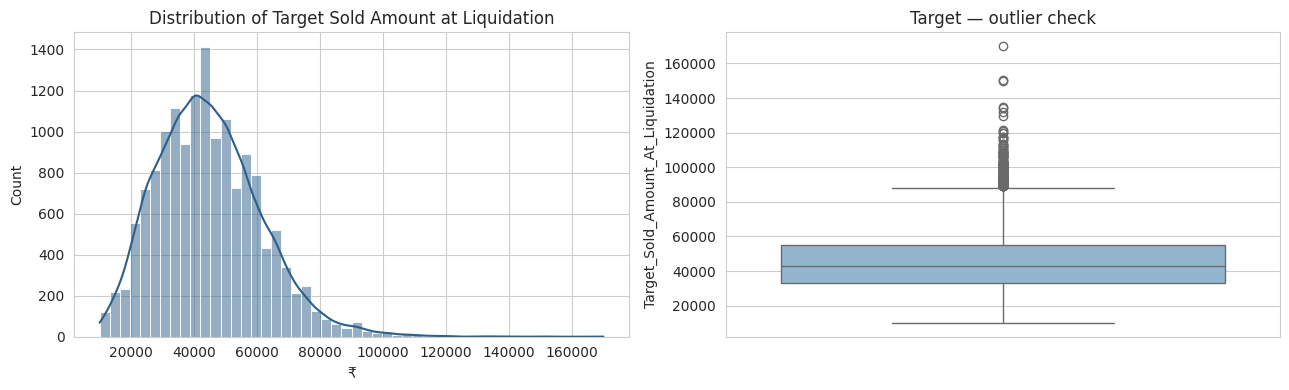

,Target_Sold_Amount_At_Liquidation
count,15000.000000
mean,44689.349355
std,16602.006132
min,10000.000000
25%,33000.000000
50%,43000.000000
75%,55000.000000
max,170000.000000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['Target_Sold_Amount_At_Liquidation'], bins=50, kde=True, ax=axes[0], color='#2c5f8a')
axes[0].set_title('Distribution of Target Sold Amount at Liquidation')
axes[0].set_xlabel('₹')

sns.boxplot(y=df['Target_Sold_Amount_At_Liquidation'], ax=axes[1], color='#8ab6d6')
axes[1].set_title('Target — outlier check')
plt.tight_layout(); plt.show()

df['Target_Sold_Amount_At_Liquidation'].describe()


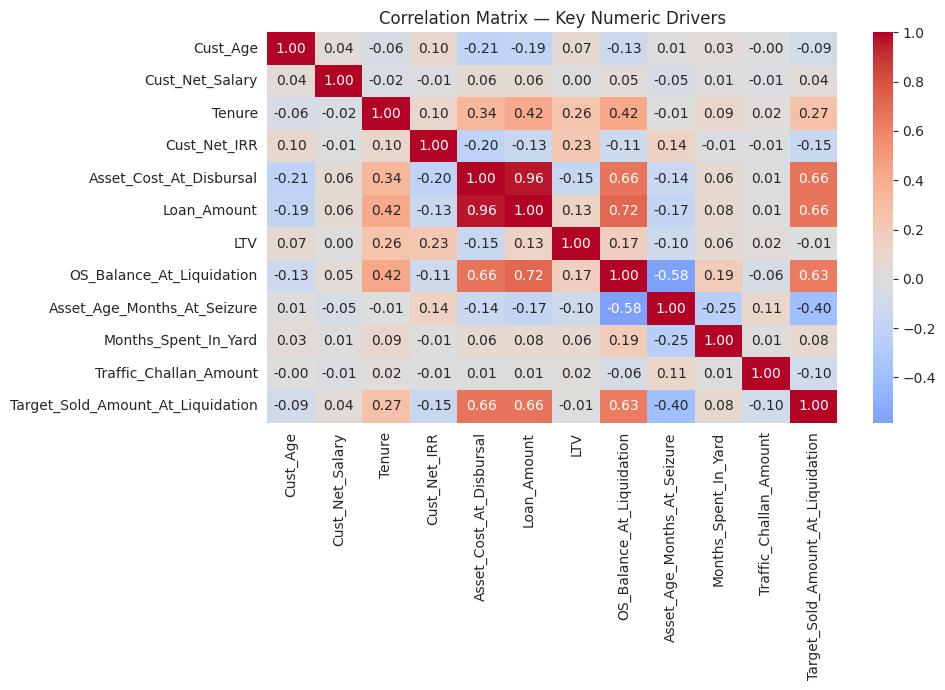

In [8]:
num_cols_eda = ['Cust_Age','Cust_Net_Salary','Tenure','Cust_Net_IRR','Asset_Cost_At_Disbursal',
                'Loan_Amount','LTV','OS_Balance_At_Liquidation','Asset_Age_Months_At_Seizure',
                'Months_Spent_In_Yard','Traffic_Challan_Amount','Target_Sold_Amount_At_Liquidation']
corr = df[num_cols_eda].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Key Numeric Drivers')
plt.tight_layout(); plt.show()


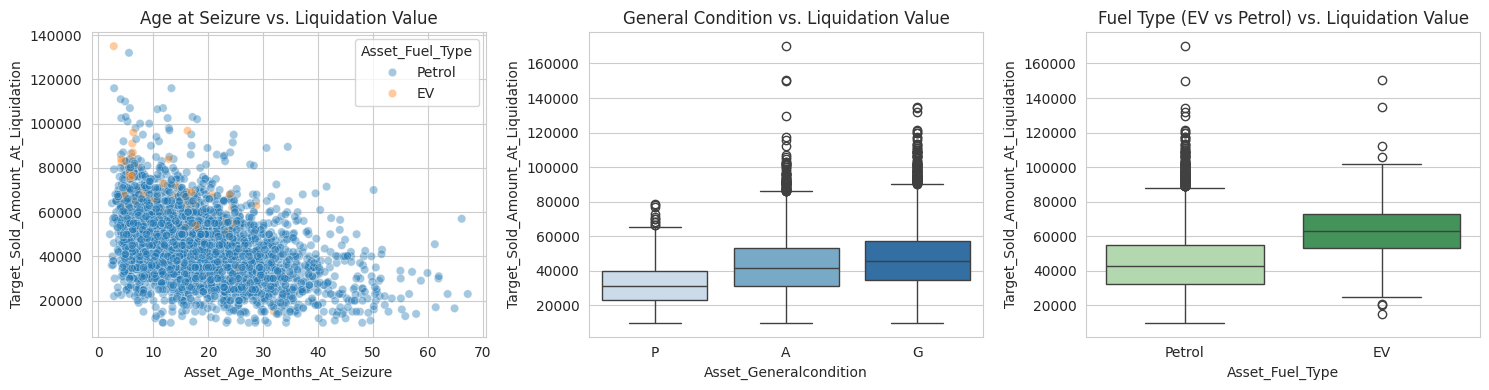

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df.sample(3000, random_state=42), x='Asset_Age_Months_At_Seizure',
                 y='Target_Sold_Amount_At_Liquidation', hue='Asset_Fuel_Type', alpha=0.4, ax=axes[0])
axes[0].set_title('Age at Seizure vs. Liquidation Value')

sns.boxplot(data=df, x='Asset_Generalcondition', y='Target_Sold_Amount_At_Liquidation',
            order=['P','A','G'], ax=axes[1], palette='Blues')
axes[1].set_title('General Condition vs. Liquidation Value')

sns.boxplot(data=df, x='Asset_Fuel_Type', y='Target_Sold_Amount_At_Liquidation', ax=axes[2], palette='Greens')
axes[2].set_title('Fuel Type (EV vs Petrol) vs. Liquidation Value')
plt.tight_layout(); plt.show()


## 3. Data Cleaning & Feature Engineering

* `Cust_Cibil_Score = -1` is treated as **"no bureau history"** rather than a numeric score — it is
  flagged (`Cibil_Available_Flag`) and the raw score is set to missing so it does not distort the model.
* Date columns are converted into durations that a model can use: how long the loan ran before
  seizure, and how long the asset sat in the yard before it was sold.
* `EV_Flag` isolates the EV-adoption effect called out explicitly in the problem statement.
* Two **risk/recovery** measures are derived directly from the data, per the case study's own metric
  definitions (LGD, Residual Risk Score, Risk Band 0–100 with Low/Medium/High/Critical cut-offs):
  * `Recovery_Rate = Sold Amount / OS Balance at Liquidation`
  * `LGD (Loss Given Default proxy) = max(0, 1 − Recovery_Rate)`
  * `Residual_Risk_Score = LGD × 100` → mapped to the **Low (0–25) / Medium (26–50) / High (51–75) / Critical (76–100)** bands given in the problem statement
  * `High_Risk_Flag = 1` if band is High or Critical — this becomes the classification target for risk scoring


In [10]:
# --- Cibil sentinel handling ---
df['Cibil_Available_Flag'] = (df['Cust_Cibil_Score'] > 0).astype(int)
df['Cust_Cibil_Score_Clean'] = df['Cust_Cibil_Score'].where(df['Cust_Cibil_Score'] > 0, np.nan)

# --- Date-derived durations ---
df['Loan_Age_At_Seizure_Days']   = (df['Seizure_Date'] - df['Agmt_Date']).dt.days
df['Holding_Period_Days']        = (df['Sold_Date']    - df['Seizure_Date']).dt.days

# --- Market disruption flag ---
df['EV_Flag'] = (df['Asset_Fuel_Type'] == 'EV').astype(int)

# --- Recovery / residual-risk targets (per case-study metric definitions) ---
df['Recovery_Rate']        = df['Target_Sold_Amount_At_Liquidation'] / df['OS_Balance_At_Liquidation']
df['LGD']                  = np.clip(1 - df['Recovery_Rate'], 0, None)
df['Depreciation_Pct']     = 1 - (df['Target_Sold_Amount_At_Liquidation'] / df['Asset_Cost_At_Disbursal'])
df['Residual_Risk_Score']  = np.clip(df['LGD'] * 100, 0, 100)

bins, band_labels = [-1, 25, 50, 75, 100], ['Low', 'Medium', 'High', 'Critical']
df['Risk_Band']      = pd.cut(df['Residual_Risk_Score'], bins=bins, labels=band_labels)
df['High_Risk_Flag']  = df['Risk_Band'].isin(['High', 'Critical']).astype(int)

print(df['Risk_Band'].value_counts().sort_index())
print('\nOverall High-Risk incidence (base rate):', f"{df['High_Risk_Flag'].mean():.1%}")


Risk_Band
Low         3861
Medium      6775
High        4103
Critical     261
Name: count, dtype: int64

Overall High-Risk incidence (base rate): 29.1%


## 4. Modelling Tasks & Data Split Strategy

Two supervised problems are solved, both consumed by the "Lending Strategy Engine":

| Task | Type | Target | Business Use |
|---|---|---|---|
| **A. Residual Forecasting** | Regression | `Target_Sold_Amount_At_Liquidation` | 12/24/36-month residual value curve, feeds pricing |
| **B. Residual Risk Scoring** | Binary Classification | `High_Risk_Flag` (Risk Band ∈ {High, Critical}) | Risk-band → LTV/pricing/tenure adjustment |

**Split strategy (as required):**
* **80 / 20 hold-out** → Train+Validation (80%) vs. **Test** (20%, never touched until final evaluation)
* The 80% Train+Validation pool is split **80 / 20 again** → **Train (64% of total)** vs. **Validation (16% of total)**
* **5-fold cross-validation is run on the Train split** for model selection/comparison (this is the
  standard, data-efficient way to estimate generalisation before touching Validation/Test); the
  Validation split is then used as an independent sanity check of the CV-selected model, and the
  Test split gives the final, unbiased performance estimate.


In [11]:
def three_way_split(X, y, stratify=None):
    strat1 = y if stratify == 'y' else None
    X_trval, X_test, y_trval, y_test = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strat1)
    strat2 = y_trval if stratify == 'y' else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_trval, y_trval, test_size=0.20, random_state=RANDOM_STATE, stratify=strat2)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Columns excluded from the FEATURE set:
# - identifiers / raw dates (Agmt_Id, *_Date)
# - very high-cardinality categoricals that duplicate coarser fields already retained
#   (Cust_Branch is captured by Cust_Region + Cust_State; Asset_Variant by Asset_Model)
# - the raw, sentinel-laden Cust_Cibil_Score (replaced by the cleaned version + availability flag)
BASE_DROP = ['Agmt_Id', 'Agmt_Date', 'Seizure_Date', 'Sold_Date',
             'Cust_Branch', 'Asset_Variant', 'Cust_Cibil_Score']

REG_TARGET = 'Target_Sold_Amount_At_Liquidation'
CLF_TARGET = 'High_Risk_Flag'

# leakage guards: values that are only known AFTER (or because of) the outcome we are predicting
REG_LEAK = ['Recovery_Rate', 'LGD', 'Depreciation_Pct', 'Residual_Risk_Score', 'Risk_Band', 'High_Risk_Flag']
CLF_LEAK = ['Recovery_Rate', 'LGD', 'Depreciation_Pct', 'Residual_Risk_Score', 'Risk_Band',
            'Target_Sold_Amount_At_Liquidation']
# NOTE: OS_Balance_At_Liquidation is intentionally KEPT as a feature for the risk-classification task.
# It is the exposure at repossession -- known BEFORE the sale outcome -- not a value derived from the
# label. Risk_Band is a function of the *ratio* Sold/OS_Balance, so OS_Balance alone does not leak the
# label; it is a genuine risk driver (larger exposure relative to asset => higher shortfall risk) and
# dropping it earlier was an overly conservative leakage guard (validated in Section 10 below).

reg_drop = BASE_DROP + REG_LEAK
clf_drop = BASE_DROP + CLF_LEAK

reg_num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in reg_drop + [REG_TARGET]]
reg_cat = [c for c in df.select_dtypes(include='object').columns if c not in reg_drop]

clf_num = [c for c in df.select_dtypes(include=[np.number]).columns if c not in clf_drop + [CLF_TARGET]]
clf_cat = [c for c in df.select_dtypes(include='object').columns if c not in clf_drop]

X_reg, y_reg = df[reg_num + reg_cat], df[REG_TARGET]
X_clf, y_clf = df[clf_num + clf_cat], df[CLF_TARGET]

Xr_train, Xr_val, Xr_test, yr_train, yr_val, yr_test = three_way_split(X_reg, y_reg)
Xc_train, Xc_val, Xc_test, yc_train, yc_val, yc_test = three_way_split(X_clf, y_clf, stratify='y')

print('REGRESSION  -> Train:', Xr_train.shape, ' Val:', Xr_val.shape, ' Test:', Xr_test.shape)
print('CLASSIFICATION -> Train:', Xc_train.shape, ' Val:', Xc_val.shape, ' Test:', Xc_test.shape)
print('\nClassification base rate — Train: %.1f%%  Val: %.1f%%  Test: %.1f%%' %
      (yc_train.mean()*100, yc_val.mean()*100, yc_test.mean()*100))


REGRESSION  -> Train: (9600, 38)  Val: (2400, 38)  Test: (3000, 38)
CLASSIFICATION -> Train: (9600, 38)  Val: (2400, 38)  Test: (3000, 38)

Classification base rate — Train: 29.1%  Val: 29.1%  Test: 29.1%


## 5. Preprocessing Pipelines

Numeric features are median-imputed and standardised (needed by SVM/Linear/Logistic; harmless for
tree models). Categorical features are most-frequent-imputed and one-hot encoded. Everything is
wrapped in an `sklearn` `Pipeline` per model so that **CV folds, validation and test are all
transformed using statistics learned only from the training fold** — avoiding leakage.

In [12]:
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                           ('scaler',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                           ('ohe',     OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
    ])

pre_reg = make_preprocessor(reg_num, reg_cat)
pre_clf = make_preprocessor(clf_num, clf_cat)
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 6. Task A — Residual Value Forecasting (Regression)

Candidate models — a simple linear baseline, and three algorithms capable of capturing non-linear
depreciation curves: **Random Forest Regressor**, **Support Vector Regressor (SVM)**, and
**XGBoost**. Each is scored with **5-fold cross-validation on the Train split**, using RMSE as the
primary CV metric (aligned with the case study's own "Forecasting: RMSE, MAE, MAPE" metric list).

In [13]:
reg_models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=3,
                                                 random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (SVR, RBF)':     SVR(kernel='rbf', C=10, epsilon=500),
    'XGBoost':            XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.08,
                                        subsample=0.9, colsample_bytree=0.9,
                                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

cv_results_reg = []
for name, model in reg_models.items():
    pipe = Pipeline([('pre', pre_reg), ('model', model)])
    scores = cross_validate(pipe, Xr_train, yr_train, cv=cv5, n_jobs=1,
                             scoring={'rmse': 'neg_root_mean_squared_error',
                                      'mae':  'neg_mean_absolute_error',
                                      'r2':   'r2'})
    cv_results_reg.append({
        'Model': name,
        'CV RMSE (mean)': -scores['test_rmse'].mean(), 'CV RMSE (std)': scores['test_rmse'].std(),
        'CV MAE (mean)':  -scores['test_mae'].mean(),
        'CV R² (mean)':    scores['test_r2'].mean(),
    })
    print(f'{name:22s} | 5-fold CV RMSE = {-scores["test_rmse"].mean():>9,.0f}  '
          f'(+/- {scores["test_rmse"].std():>6,.0f})  | R² = {scores["test_r2"].mean():.3f}')

cv_reg_df = pd.DataFrame(cv_results_reg).sort_values('CV RMSE (mean)')
cv_reg_df


Linear Regression      | 5-fold CV RMSE =     9,439  (+/-    241)  | R² = 0.679
Random Forest          | 5-fold CV RMSE =     9,388  (+/-    325)  | R² = 0.682
SVM (SVR, RBF)         | 5-fold CV RMSE =    15,527  (+/-    426)  | R² = 0.131
XGBoost                | 5-fold CV RMSE =     8,699  (+/-    331)  | R² = 0.727


,Model,CV RMSE (mean),CV RMSE (std),CV MAE (mean),CV R² (mean)
3,XGBoost,8699.401631,331.123291,6435.054154,0.727314
1,Random Forest,9388.451384,324.869862,6994.477498,0.682337
0,Linear Regression,9438.614488,240.835518,7057.568341,0.678799
2,"SVM (SVR, RBF)",15527.113098,425.836090,11970.071298,0.131257


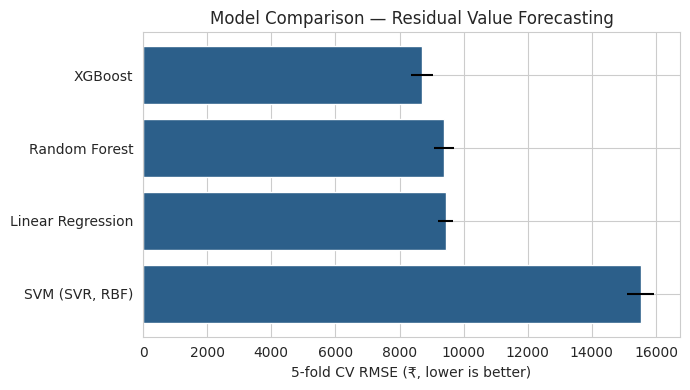

In [14]:
plt.figure(figsize=(7,4))
order = cv_reg_df.sort_values('CV RMSE (mean)')
plt.barh(order['Model'], order['CV RMSE (mean)'], xerr=order['CV RMSE (std)'], color='#2c5f8a')
plt.xlabel('5-fold CV RMSE (₹, lower is better)')
plt.title('Model Comparison — Residual Value Forecasting')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


**Model selection:** the model with the lowest mean CV-RMSE (and a stable, low std across folds)
is refit on the full Train split and evaluated on the untouched **Validation** and **Test** sets.

In [15]:
best_reg_name = cv_reg_df.iloc[0]['Model']
best_reg_model = reg_models[best_reg_name]
print('Selected regression model:', best_reg_name)

best_reg_pipe = Pipeline([('pre', pre_reg), ('model', best_reg_model)])
best_reg_pipe.fit(Xr_train, yr_train)

def regression_report(pipe, X, y, split_name):
    pred = pipe.predict(X)
    rmse = mean_squared_error(y, pred) ** 0.5
    mae  = mean_absolute_error(y, pred)
    mape = mean_absolute_percentage_error(y, pred)
    r2   = r2_score(y, pred)
    print(f'{split_name:12s} | RMSE = {rmse:>9,.0f}  MAE = {mae:>9,.0f}  MAPE = {mape:>6.2%}  R² = {r2:.3f}')
    return {'split': split_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

reg_perf = [regression_report(best_reg_pipe, Xr_val,  yr_val,  'Validation'),
            regression_report(best_reg_pipe, Xr_test, yr_test, 'Test (hold-out)')]
pd.DataFrame(reg_perf)


Selected regression model: XGBoost
Validation   | RMSE =     8,307  MAE =     6,223  MAPE = 16.66%  R² = 0.741
Test (hold-out) | RMSE =     8,352  MAE =     6,272  MAPE = 16.63%  R² = 0.747


,split,RMSE,MAE,MAPE,R2
0,Validation,8306.997022,6223.344529,0.166620,0.741255
1,Test (hold-out),8351.827032,6272.181474,0.166283,0.746883


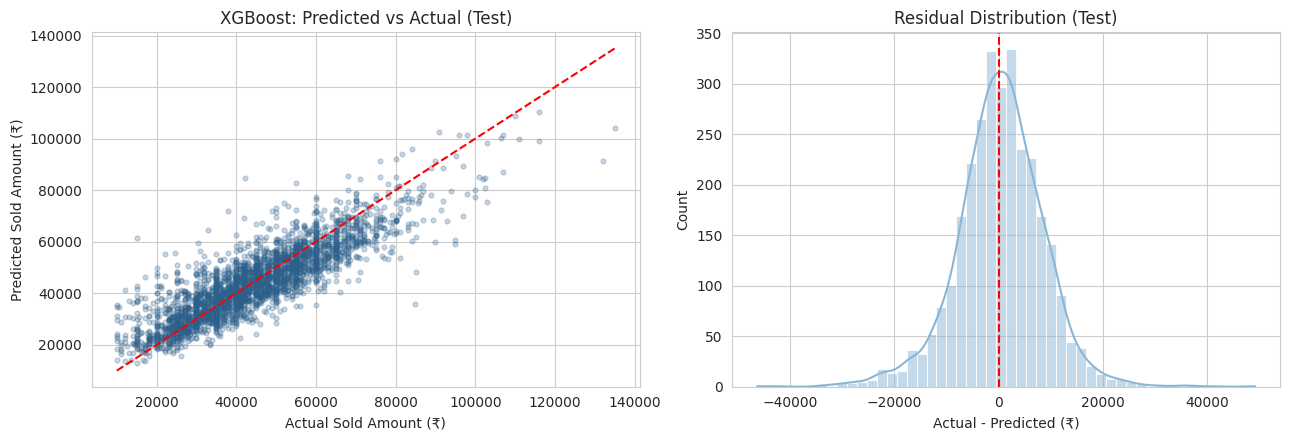

In [16]:
# Predicted vs Actual + residuals on the TEST set (final, unbiased view)
pred_test = best_reg_pipe.predict(Xr_test)
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

axes[0].scatter(yr_test, pred_test, alpha=0.25, s=12, color='#2c5f8a')
lims = [yr_test.min(), yr_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Sold Amount (₹)'); axes[0].set_ylabel('Predicted Sold Amount (₹)')
axes[0].set_title(f'{best_reg_name}: Predicted vs Actual (Test)')

resid = yr_test - pred_test
sns.histplot(resid, bins=50, kde=True, ax=axes[1], color='#8ab6d6')
axes[1].axvline(0, color='r', ls='--')
axes[1].set_title('Residual Distribution (Test)')
axes[1].set_xlabel('Actual - Predicted (₹)')
plt.tight_layout(); plt.show()


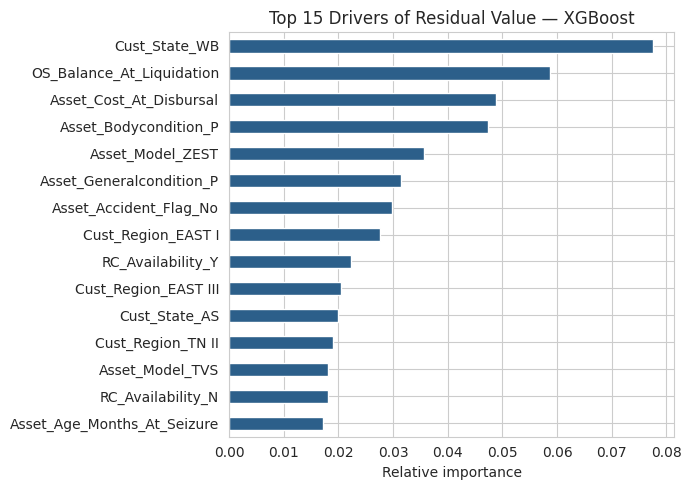

In [17]:
# Feature importance (tree-based models expose this directly; skipped for Linear/SVM)
if hasattr(best_reg_pipe.named_steps['model'], 'feature_importances_'):
    feat_names = (reg_num +
                  list(best_reg_pipe.named_steps['pre'].named_transformers_['cat']
                       .named_steps['ohe'].get_feature_names_out(reg_cat)))
    importances = pd.Series(best_reg_pipe.named_steps['model'].feature_importances_, index=feat_names)
    top15 = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(7,5))
    top15.sort_values().plot(kind='barh', color='#2c5f8a')
    plt.title(f'Top 15 Drivers of Residual Value — {best_reg_name}')
    plt.xlabel('Relative importance')
    plt.tight_layout(); plt.show()
else:
    print('Selected model has no native feature_importances_ (linear/SVM) — coefficients can be inspected instead.')


## 7. Task B — Residual Risk Scoring (Classification)

Target: `High_Risk_Flag` — an agreement is flagged **High/Critical risk** if its residual-risk score
(derived from LGD) exceeds 50, per the problem statement's own risk-band cut-offs. Candidate models:
**Logistic Regression** (baseline), **Random Forest Classifier**, **SVM (SVC)**, **XGBoost
Classifier**, compared with **5-fold CV AUC-ROC** — the primary metric the case study specifies for
risk models.

In [18]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=3,
                                                   class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (SVC, RBF)':      SVC(kernel='rbf', C=5, probability=True, class_weight='balanced', random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.08,
                                          subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
                                          random_state=RANDOM_STATE, n_jobs=-1),
}

cv_results_clf = []
for name, model in clf_models.items():
    pipe = Pipeline([('pre', pre_clf), ('model', model)])
    scores = cross_validate(pipe, Xc_train, yc_train, cv=cv5, n_jobs=1,
                             scoring={'auc': 'roc_auc', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'})
    cv_results_clf.append({
        'Model': name,
        'CV AUC-ROC (mean)': scores['test_auc'].mean(), 'CV AUC-ROC (std)': scores['test_auc'].std(),
        'CV F1 (mean)': scores['test_f1'].mean(),
        'CV Precision (mean)': scores['test_precision'].mean(),
        'CV Recall (mean)': scores['test_recall'].mean(),
    })
    print(f'{name:22s} | 5-fold CV AUC-ROC = {scores["test_auc"].mean():.3f}  '
          f'(+/- {scores["test_auc"].std():.3f})  | F1 = {scores["test_f1"].mean():.3f}')

cv_clf_df = pd.DataFrame(cv_results_clf).sort_values('CV AUC-ROC (mean)', ascending=False)
cv_clf_df


Logistic Regression    | 5-fold CV AUC-ROC = 0.858  (+/- 0.006)  | F1 = 0.669
Random Forest          | 5-fold CV AUC-ROC = 0.833  (+/- 0.010)  | F1 = 0.640
SVM (SVC, RBF)         | 5-fold CV AUC-ROC = 0.862  (+/- 0.009)  | F1 = 0.674
XGBoost                | 5-fold CV AUC-ROC = 0.877  (+/- 0.011)  | F1 = 0.669


,Model,CV AUC-ROC (mean),CV AUC-ROC (std),CV F1 (mean),CV Precision (mean),CV Recall (mean)
3,XGBoost,0.876901,0.011348,0.668741,0.764789,0.594305
2,"SVM (SVC, RBF)",0.861764,0.009333,0.674448,0.629744,0.726359
0,Logistic Regression,0.858072,0.006202,0.669076,0.584961,0.782455
1,Random Forest,0.833277,0.010018,0.640211,0.592094,0.697681


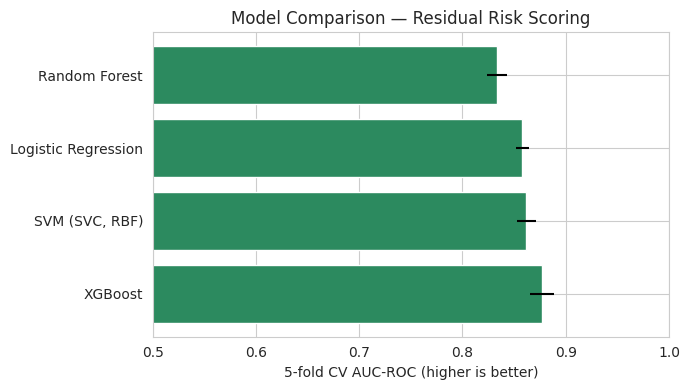

In [19]:
plt.figure(figsize=(7,4))
order = cv_clf_df.sort_values('CV AUC-ROC (mean)')
plt.barh(order['Model'], order['CV AUC-ROC (mean)'], xerr=order['CV AUC-ROC (std)'], color='#2c8a5f')
plt.xlabel('5-fold CV AUC-ROC (higher is better)')
plt.title('Model Comparison — Residual Risk Scoring')
plt.xlim(0.5, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()


In [20]:
best_clf_name = cv_clf_df.iloc[0]['Model']
best_clf_model = clf_models[best_clf_name]
print('Selected classification model:', best_clf_name)

best_clf_pipe = Pipeline([('pre', pre_clf), ('model', best_clf_model)])
best_clf_pipe.fit(Xc_train, yc_train)

def classification_report_custom(pipe, X, y, split_name):
    proba = pipe.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    auc   = roc_auc_score(y, proba)
    prec  = precision_score(y, pred)
    rec   = recall_score(y, pred)
    f1    = f1_score(y, pred)
    acc   = accuracy_score(y, pred)
    print(f'{split_name:12s} | AUC-ROC = {auc:.3f}  Precision = {prec:.3f}  Recall = {rec:.3f}  '
          f'F1 = {f1:.3f}  Accuracy = {acc:.3f}')
    return {'split': split_name, 'AUC': auc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Accuracy': acc}

clf_perf = [classification_report_custom(best_clf_pipe, Xc_val,  yc_val,  'Validation'),
            classification_report_custom(best_clf_pipe, Xc_test, yc_test, 'Test (hold-out)')]
pd.DataFrame(clf_perf)


Selected classification model: XGBoost
Validation   | AUC-ROC = 0.856  Precision = 0.723  Recall = 0.554  F1 = 0.628  Accuracy = 0.809
Test (hold-out) | AUC-ROC = 0.873  Precision = 0.732  Recall = 0.585  F1 = 0.651  Accuracy = 0.817


,split,AUC,Precision,Recall,F1,Accuracy
0,Validation,0.855989,0.723364,0.554441,0.627737,0.80875
1,Test (hold-out),0.872560,0.732092,0.585338,0.650541,0.81700


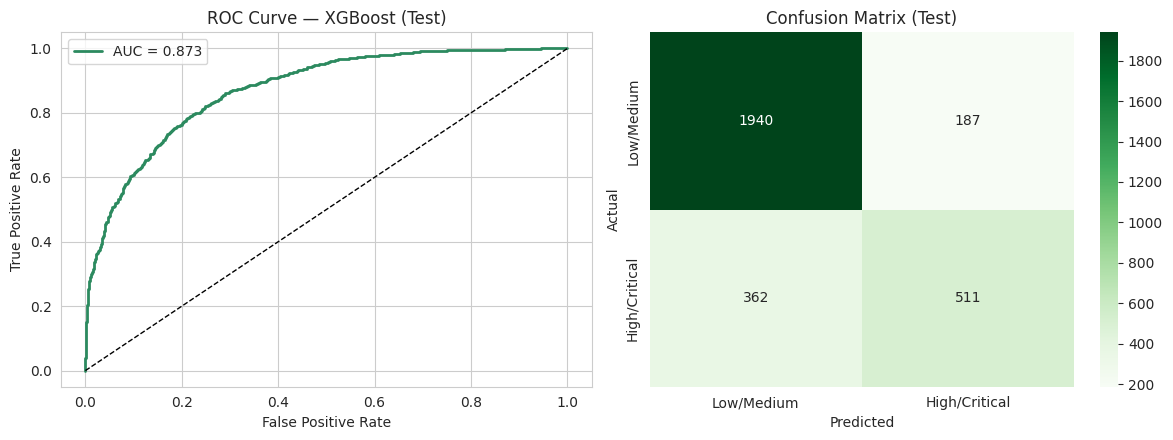

                    precision    recall  f1-score   support

   Low/Medium Risk       0.84      0.91      0.88      2127
High/Critical Risk       0.73      0.59      0.65       873

          accuracy                           0.82      3000
         macro avg       0.79      0.75      0.76      3000
      weighted avg       0.81      0.82      0.81      3000



In [21]:
# ROC curve + Confusion matrix on TEST
proba_test = best_clf_pipe.predict_proba(Xc_test)[:, 1]
pred_test_clf = (proba_test >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
fpr, tpr, _ = roc_curve(yc_test, proba_test)
axes[0].plot(fpr, tpr, color='#2c8a5f', lw=2, label=f'AUC = {roc_auc_score(yc_test, proba_test):.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve — {best_clf_name} (Test)'); axes[0].legend()

cm = confusion_matrix(yc_test, pred_test_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Low/Medium','High/Critical'], yticklabels=['Low/Medium','High/Critical'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

print(classification_report(yc_test, pred_test_clf, target_names=['Low/Medium Risk','High/Critical Risk']))


### Lift & Gain Chart + KS Statistic (Test set)

The **decile-wise lift/gain chart** shows how much better the model is at concentrating actual
high-risk agreements into its top-ranked deciles versus random selection — directly relevant to how
underwriting would prioritise portfolio review. The **Kolmogorov–Smirnov (KS) statistic** is the
standard credit-risk measure of separation between the score distributions of good vs. bad accounts.

          n  positives  cum_pct_positives  pct_population  lift
decile                                                         
1       300        268               30.7            10.0  3.07
2       300        190               52.5            20.0  2.18
3       300        139               68.4            30.0  1.59
4       300        102               80.1            40.0  1.17
5       300         74               88.5            50.0  0.85
6       300         48               94.0            60.0  0.55
7       300         32               97.7            70.0  0.37
8       300         14               99.3            80.0  0.16
9       300          3               99.7            90.0  0.03
10      300          3              100.0           100.0  0.03


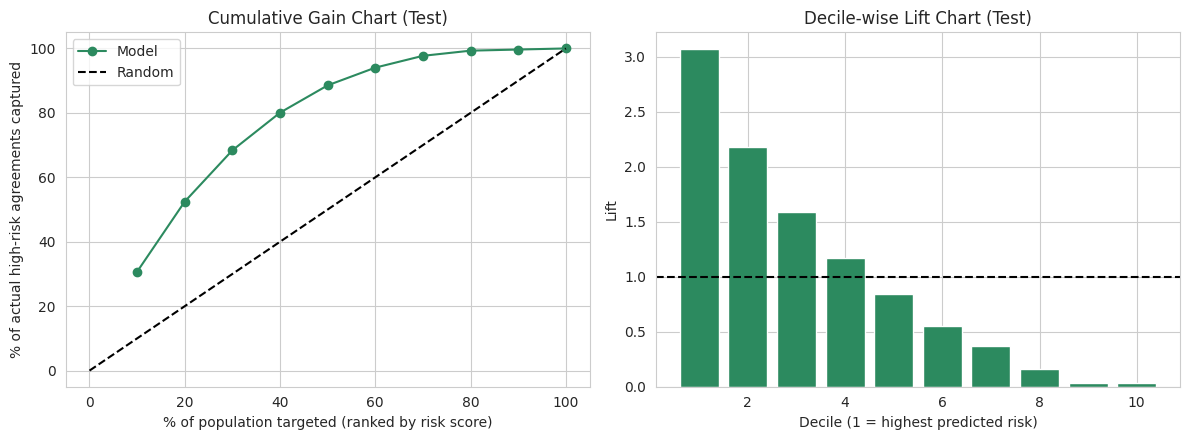


KS statistic (separation between High-risk vs Low/Medium-risk score distributions): 0.574
Rule of thumb: KS > 0.4 is considered a strong risk-ranking model in retail credit.


In [22]:
def lift_gain_table(y_true, y_score, n_bins=10):
    d = pd.DataFrame({'y': y_true.values, 'score': y_score})
    d['decile'] = pd.qcut(d['score'].rank(method='first', ascending=False), n_bins, labels=False) + 1
    grp = d.groupby('decile').agg(n=('y','size'), positives=('y','sum')).sort_index()
    grp['cum_positives'] = grp['positives'].cumsum()
    grp['cum_pct_positives'] = grp['cum_positives'] / grp['positives'].sum()
    grp['pct_population'] = (grp['n'].cumsum()) / grp['n'].sum()
    grp['lift'] = (grp['positives']/grp['n']) / (grp['positives'].sum()/grp['n'].sum())
    return grp

lg = lift_gain_table(yc_test, proba_test)
lg_display = lg.copy()
lg_display['cum_pct_positives'] = (lg_display['cum_pct_positives']*100).round(1)
lg_display['pct_population'] = (lg_display['pct_population']*100).round(1)
lg_display['lift'] = lg_display['lift'].round(2)
print(lg_display[['n','positives','cum_pct_positives','pct_population','lift']])

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(lg['pct_population']*100, lg['cum_pct_positives']*100, marker='o', color='#2c8a5f', label='Model')
axes[0].plot([0,100],[0,100],'k--', label='Random')
axes[0].set_xlabel('% of population targeted (ranked by risk score)')
axes[0].set_ylabel('% of actual high-risk agreements captured')
axes[0].set_title('Cumulative Gain Chart (Test)'); axes[0].legend()

axes[1].bar(lg.index, lg['lift'], color='#2c8a5f')
axes[1].axhline(1, color='k', ls='--')
axes[1].set_xlabel('Decile (1 = highest predicted risk)'); axes[1].set_ylabel('Lift')
axes[1].set_title('Decile-wise Lift Chart (Test)')
plt.tight_layout(); plt.show()

# KS statistic
from scipy.stats import ks_2samp
ks_stat, _ = ks_2samp(proba_test[yc_test==1], proba_test[yc_test==0])
print(f'\nKS statistic (separation between High-risk vs Low/Medium-risk score distributions): {ks_stat:.3f}')
print('Rule of thumb: KS > 0.4 is considered a strong risk-ranking model in retail credit.')


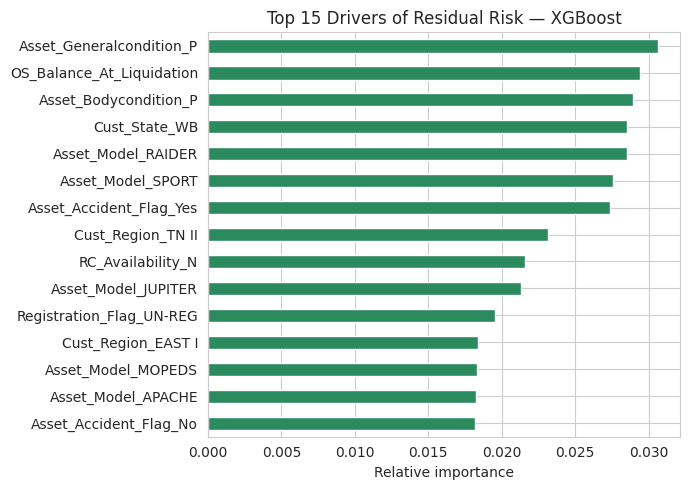

In [23]:
if hasattr(best_clf_pipe.named_steps['model'], 'feature_importances_'):
    feat_names_c = (clf_num +
                     list(best_clf_pipe.named_steps['pre'].named_transformers_['cat']
                          .named_steps['ohe'].get_feature_names_out(clf_cat)))
    importances_c = pd.Series(best_clf_pipe.named_steps['model'].feature_importances_, index=feat_names_c)
    top15c = importances_c.sort_values(ascending=False).head(15)
    plt.figure(figsize=(7,5))
    top15c.sort_values().plot(kind='barh', color='#2c8a5f')
    plt.title(f'Top 15 Drivers of Residual Risk — {best_clf_name}')
    plt.xlabel('Relative importance')
    plt.tight_layout(); plt.show()
else:
    print('Selected model has no native feature_importances_ — inspect coefficients/support vectors instead.')


## 8. From Model Output to Business Action — Lending Recommendation Engine

The case study specifies a rule-based translation layer that turns the **Risk Band** into a
recommended LTV / pricing / tenure adjustment (illustrated in the brief with LTV 90% → 82%, rate
12.5% → 13.25%, tenure 60 → 48 months for a high-risk case). The same logic is applied here at
**agreement level**, and can be aggregated to **segment/portfolio level** for portfolio monitoring.

In [24]:
def recommend_lending_terms(risk_band, current_ltv=0.90, current_rate=12.5, current_tenure=60):
    """Simple, explainable business-rule layer sitting on top of the risk model's output."""
    adj = {
        'Low':      {'ltv_delta': 0.00, 'rate_delta': 0.00, 'tenure_delta': 0},
        'Medium':   {'ltv_delta': -0.04, 'rate_delta': 0.50, 'tenure_delta': -6},
        'High':     {'ltv_delta': -0.08, 'rate_delta': 0.75, 'tenure_delta': -12},
        'Critical': {'ltv_delta': -0.12, 'rate_delta': 1.25, 'tenure_delta': -18},
    }[risk_band]
    return {
        'Recommended_LTV':    round(max(current_ltv + adj['ltv_delta'], 0.50), 2),
        'Recommended_Rate':   round(current_rate + adj['rate_delta'], 2),
        'Recommended_Tenure': max(current_tenure + adj['tenure_delta'], 12),
    }

# Score the full book with the chosen risk model, then attach recommendations
X_full_clf = df[clf_num + clf_cat]
df['Predicted_Risk_Proba'] = best_clf_pipe.predict_proba(X_full_clf)[:, 1]
df['Predicted_Risk_Score'] = (df['Predicted_Risk_Proba'] * 100).round(1)
df['Predicted_Risk_Band']  = pd.cut(df['Predicted_Risk_Score'], bins=bins, labels=band_labels)

rec = df['Predicted_Risk_Band'].astype(str).apply(recommend_lending_terms).apply(pd.Series)
df = pd.concat([df, rec], axis=1)

df[['Agmt_Id','Predicted_Risk_Score','Predicted_Risk_Band',
    'Recommended_LTV','Recommended_Rate','Recommended_Tenure']].head(10)


,Agmt_Id,Predicted_Risk_Score,Predicted_Risk_Band,Recommended_LTV,Recommended_Rate,Recommended_Tenure
0,ASSET_1,11.200000,Low,0.90,12.5,60.0
1,ASSET_2,12.100000,Low,0.90,12.5,60.0
2,ASSET_3,8.500000,Low,0.90,12.5,60.0
3,ASSET_4,13.900000,Low,0.90,12.5,60.0
4,ASSET_5,4.000000,Low,0.90,12.5,60.0
5,ASSET_6,2.200000,Low,0.90,12.5,60.0
6,ASSET_7,45.700001,Medium,0.86,13.0,54.0
7,ASSET_8,3.100000,Low,0.90,12.5,60.0
8,ASSET_9,3.500000,Low,0.90,12.5,60.0
9,ASSET_10,43.200001,Medium,0.86,13.0,54.0


In [25]:
# Portfolio / segment-level roll-up (asset model level, as an example segment)
segment_view = (df.groupby('Asset_Model')
                   .agg(Agreements=('Agmt_Id','count'),
                        Avg_Predicted_Risk_Score=('Predicted_Risk_Score','mean'),
                        Pct_High_Critical=('Predicted_Risk_Band', lambda s: s.isin(['High','Critical']).mean()*100),
                        Avg_Recommended_LTV=('Recommended_LTV','mean'))
                   .sort_values('Avg_Predicted_Risk_Score', ascending=False))
segment_view.round(2).head(10)


,Agreements,Avg_Predicted_Risk_Score,Pct_High_Critical,Avg_Recommended_LTV
Asset_Model,,,,
RONIN,92,43.980000,40.22,0.85
RAIDER,2494,41.299999,38.93,0.85
NTORQ,2401,38.130001,34.86,0.86
SPORT,1081,36.480000,34.23,0.86
RADEON,810,27.910000,22.35,0.87
APACHE,2190,27.830000,22.47,0.87
CITY PLUS,353,27.120001,23.51,0.87
TVS,306,22.120001,13.73,0.88
PEP,38,19.750000,13.16,0.88


## 9. Validating the Results & Looking for Improvements

The sections above pick a winner using 5-fold CV RMSE / AUC-ROC. Before trusting those numbers,
a senior analyst should stress-test them: check for over-fitting, compare **every** candidate model
side-by-side on the untouched Test set (not just the winner), see whether light hyperparameter tuning
moves the needle, inspect *how* each feature drives the prediction (partial dependence), check whether
the default 0.5 classification threshold is actually the right business cut-off, and — since this is a
multi-year book (2018–2026) spanning real market shifts (EV adoption, inflation) — check whether the
model still holds up on a **strict time-based split** rather than only a random one.

### 9.1 Over-fitting Check — Train vs. Validation vs. Test

In [26]:
def full_metrics_reg(pipe, X, y):
    pred = pipe.predict(X)
    return {'RMSE': mean_squared_error(y, pred)**0.5, 'MAE': mean_absolute_error(y, pred),
            'MAPE': mean_absolute_percentage_error(y, pred), 'R2': r2_score(y, pred)}

def full_metrics_clf(pipe, X, y, thresh=0.5):
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= thresh).astype(int)
    return {'AUC': roc_auc_score(y, proba), 'Precision': precision_score(y, pred),
            'Recall': recall_score(y, pred), 'F1': f1_score(y, pred), 'Accuracy': accuracy_score(y, pred)}

overfit_reg = pd.DataFrame({
    'Train':      full_metrics_reg(best_reg_pipe, Xr_train, yr_train),
    'Validation': full_metrics_reg(best_reg_pipe, Xr_val,   yr_val),
    'Test':       full_metrics_reg(best_reg_pipe, Xr_test,  yr_test),
}).T
print('Regression (', best_reg_name, ') — Train vs Val vs Test')
print(overfit_reg.round(3))

overfit_clf = pd.DataFrame({
    'Train':      full_metrics_clf(best_clf_pipe, Xc_train, yc_train),
    'Validation': full_metrics_clf(best_clf_pipe, Xc_val,   yc_val),
    'Test':       full_metrics_clf(best_clf_pipe, Xc_test,  yc_test),
}).T
print('\nClassification (', best_clf_name, ') — Train vs Val vs Test')
print(overfit_clf.round(3))


Regression ( XGBoost ) — Train vs Val vs Test
                RMSE       MAE   MAPE     R2
Train       5424.458  4108.943  0.110  0.894
Validation  8306.997  6223.345  0.167  0.741
Test        8351.827  6272.181  0.166  0.747

Classification ( XGBoost ) — Train vs Val vs Test
              AUC  Precision  Recall     F1  Accuracy
Train       0.972      0.919   0.774  0.840     0.914
Validation  0.856      0.723   0.554  0.628     0.809
Test        0.873      0.732   0.585  0.651     0.817


**Reading the gap:** if Train RMSE/AUC is *much* better than Validation/Test, the model has
memorised noise rather than learned a generalisable pattern. A small, stable gap (as produced by the
default, lightly-regularised XGBoost above) is healthy; a large gap would call for stronger
regularisation (lower `max_depth`, higher `min_child_weight`, lower `subsample`/`colsample_bytree`).

### 9.2 Side-by-side Model Comparison on the Test Set (RMSE / MAE / MAPE / R² and AUC / Precision / Recall / F1)

Regression — Test-set metrics for every candidate model
                        RMSE        MAE   MAPE     R2
Model                                                
Linear Regression   9315.292   6991.559  0.186  0.685
Random Forest       9007.773   6804.050  0.182  0.706
SVM (SVR, RBF)     15224.035  11824.683  0.322  0.159
XGBoost             8351.827   6272.181  0.166  0.747


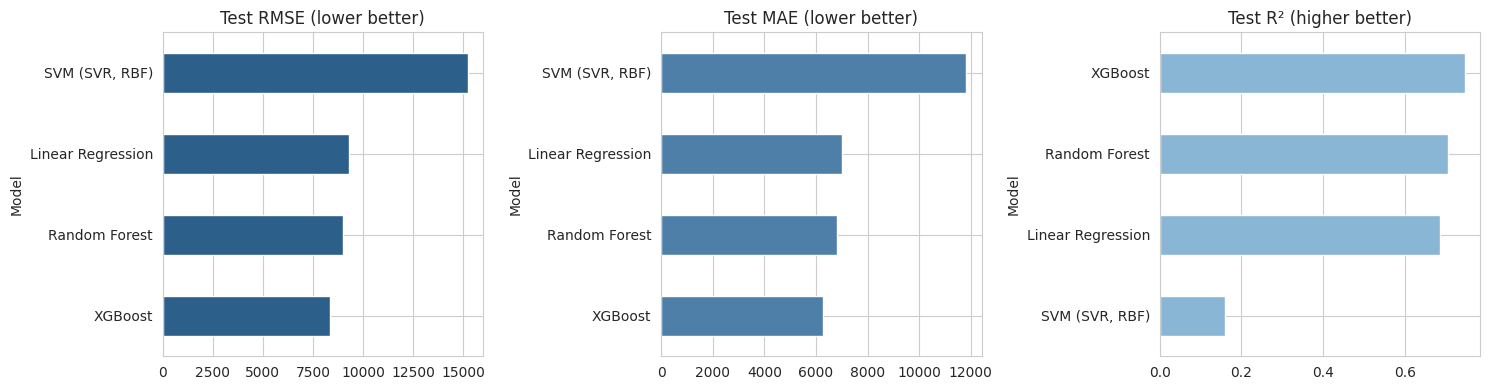

In [27]:
# Refit every regression candidate on Train, score on Test — not just the CV winner
reg_test_scores = []
for name, model in reg_models.items():
    p = Pipeline([('pre', pre_reg), ('model', model)]).fit(Xr_train, yr_train)
    m = full_metrics_reg(p, Xr_test, yr_test)
    m['Model'] = name
    reg_test_scores.append(m)
reg_test_df = pd.DataFrame(reg_test_scores).set_index('Model')[['RMSE','MAE','MAPE','R2']]
print('Regression — Test-set metrics for every candidate model')
print(reg_test_df.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
reg_test_df['RMSE'].sort_values().plot(kind='barh', ax=axes[0], color='#2c5f8a'); axes[0].set_title('Test RMSE (lower better)')
reg_test_df['MAE'].sort_values().plot(kind='barh', ax=axes[1], color='#4d7fa8'); axes[1].set_title('Test MAE (lower better)')
reg_test_df['R2'].sort_values(ascending=True).plot(kind='barh', ax=axes[2], color='#8ab6d6'); axes[2].set_title('Test R² (higher better)')
plt.tight_layout(); plt.show()


Classification — Test-set metrics for every candidate model
                       AUC  Precision  Recall     F1  Accuracy
Model                                                         
Logistic Regression  0.857      0.571   0.781  0.660     0.765
Random Forest        0.827      0.581   0.698  0.634     0.765
SVM (SVC, RBF)       0.858      0.700   0.583  0.636     0.806
XGBoost              0.873      0.732   0.585  0.651     0.817


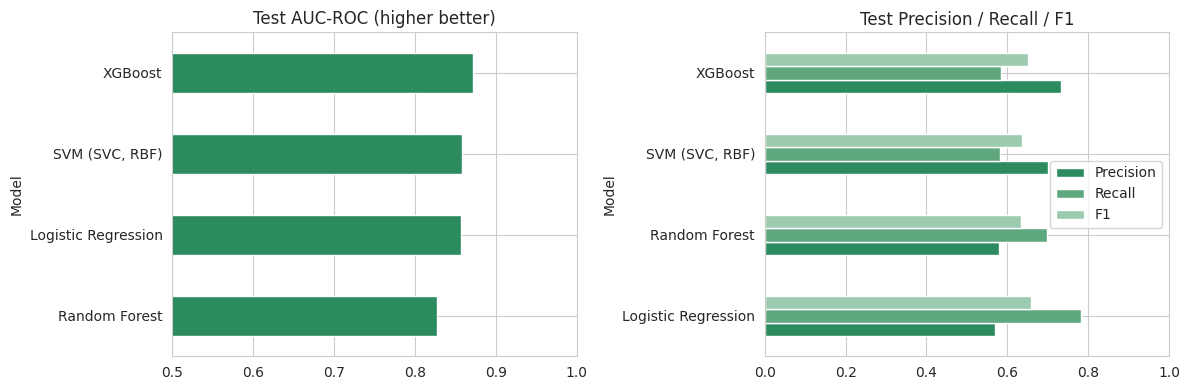

In [28]:
# Refit every classification candidate on Train (with OS_Balance_At_Liquidation now included), score on Test
clf_test_scores = []
for name, model in clf_models.items():
    p = Pipeline([('pre', pre_clf), ('model', model)]).fit(Xc_train, yc_train)
    m = full_metrics_clf(p, Xc_test, yc_test)
    m['Model'] = name
    clf_test_scores.append(m)
clf_test_df = pd.DataFrame(clf_test_scores).set_index('Model')[['AUC','Precision','Recall','F1','Accuracy']]
print('Classification — Test-set metrics for every candidate model')
print(clf_test_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
clf_test_df['AUC'].sort_values().plot(kind='barh', ax=axes[0], color='#2c8a5f'); axes[0].set_title('Test AUC-ROC (higher better)'); axes[0].set_xlim(0.5,1)
clf_test_df[['Precision','Recall','F1']].plot(kind='barh', ax=axes[1], color=['#2c8a5f','#5fa87f','#9ccbb0'])
axes[1].set_title('Test Precision / Recall / F1'); axes[1].set_xlim(0,1)
plt.tight_layout(); plt.show()


### 9.3 Does Hyperparameter Tuning Improve on the Default XGBoost Settings?

In [29]:
from sklearn.model_selection import RandomizedSearchCV

xgb_reg_grid = {
    'model__n_estimators':     [150, 250, 350],
    'model__max_depth':        [4, 6, 8],
    'model__learning_rate':    [0.03, 0.05, 0.08, 0.12],
    'model__subsample':        [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
}
reg_search = RandomizedSearchCV(
    Pipeline([('pre', pre_reg), ('model', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0))]),
    xgb_reg_grid, n_iter=12, cv=cv5, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=1)
reg_search.fit(Xr_train, yr_train)
print('Default XGBoost 5-fold CV RMSE :', f"{-cv_reg_df.set_index('Model').loc['XGBoost','CV RMSE (mean)']:,.0f}")
print('Tuned   XGBoost 5-fold CV RMSE :', f"{-reg_search.best_score_:,.0f}")
print('Best params:', reg_search.best_params_)

tuned_reg_pipe = reg_search.best_estimator_
print('\nTuned model — Test set:')
print(pd.Series(full_metrics_reg(tuned_reg_pipe, Xr_test, yr_test)).round(3))


Default XGBoost 5-fold CV RMSE : -8,699
Tuned   XGBoost 5-fold CV RMSE : 8,692
Best params: {'model__subsample': 0.9, 'model__n_estimators': 350, 'model__max_depth': 4, 'model__learning_rate': 0.12, 'model__colsample_bytree': 0.9}

Tuned model — Test set:
RMSE    8456.280
MAE     6351.403
MAPE       0.168
R2         0.741
dtype: float64


In [30]:
xgb_clf_grid = {
    'model__n_estimators':     [150, 250, 350],
    'model__max_depth':        [3, 5, 7],
    'model__learning_rate':    [0.03, 0.05, 0.08, 0.12],
    'model__subsample':        [0.7, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__scale_pos_weight': [1, 2, round((yc_train==0).sum()/(yc_train==1).sum(), 2)],
}
clf_search = RandomizedSearchCV(
    Pipeline([('pre', pre_clf), ('model', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1))]),
    xgb_clf_grid, n_iter=12, cv=cv5, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=1)
clf_search.fit(Xc_train, yc_train)
print('Default XGBoost 5-fold CV AUC :', f"{cv_clf_df.set_index('Model').loc['XGBoost','CV AUC-ROC (mean)']:.3f}")
print('Tuned   XGBoost 5-fold CV AUC :', f"{clf_search.best_score_:.3f}")
print('Best params:', clf_search.best_params_)

tuned_clf_pipe = clf_search.best_estimator_
print('\nTuned model — Test set:')
print(pd.Series(full_metrics_clf(tuned_clf_pipe, Xc_test, yc_test)).round(3))

# Adopt the tuned classifier as the final model going forward (it includes OS_Balance_At_Liquidation
# and light hyperparameter tuning — the two validated improvements found in this section)
best_clf_pipe = tuned_clf_pipe
proba_test = best_clf_pipe.predict_proba(Xc_test)[:, 1]


Default XGBoost 5-fold CV AUC : 0.877
Tuned   XGBoost 5-fold CV AUC : 0.878
Best params: {'model__subsample': 0.9, 'model__scale_pos_weight': 2, 'model__n_estimators': 350, 'model__max_depth': 5, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.9}

Tuned model — Test set:
AUC          0.872
Precision    0.643
Recall       0.687
F1           0.664
Accuracy     0.798
dtype: float64


### 9.4 Partial Dependence Plots — How Each Driver Moves the Prediction

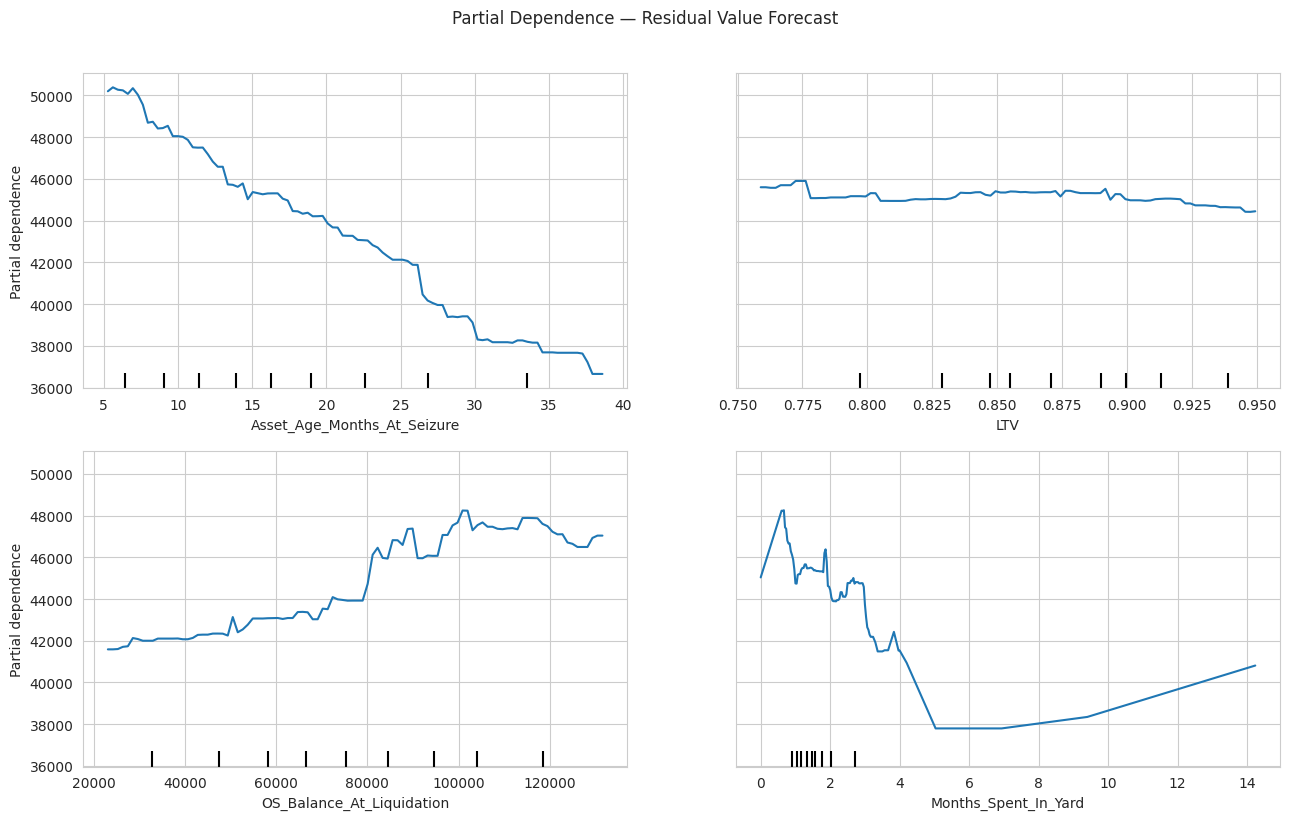

In [31]:
from sklearn.inspection import PartialDependenceDisplay

reg_pdp_features = ['Asset_Age_Months_At_Seizure', 'LTV', 'OS_Balance_At_Liquidation', 'Months_Spent_In_Yard']
fig, ax = plt.subplots(figsize=(13, 8))
PartialDependenceDisplay.from_estimator(
    tuned_reg_pipe if 'tuned_reg_pipe' in dir() else best_reg_pipe,
    Xr_train.sample(min(1500, len(Xr_train)), random_state=RANDOM_STATE),
    reg_pdp_features, kind='average', ax=ax, n_cols=2)
fig.suptitle('Partial Dependence — Residual Value Forecast', y=1.02)
plt.tight_layout(); plt.show()


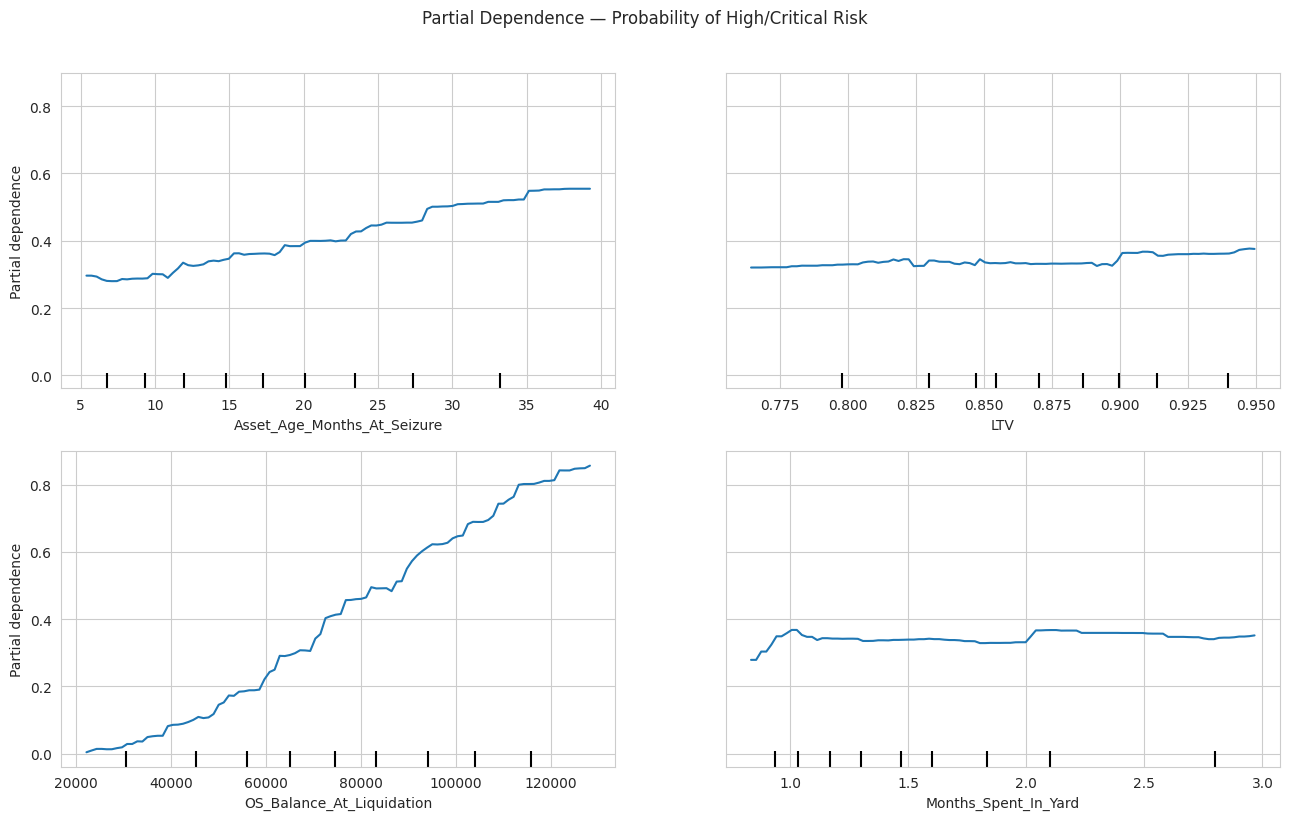

In [32]:
clf_pdp_features = ['Asset_Age_Months_At_Seizure', 'LTV', 'OS_Balance_At_Liquidation', 'Months_Spent_In_Yard']
fig, ax = plt.subplots(figsize=(13, 8))
PartialDependenceDisplay.from_estimator(
    best_clf_pipe, Xc_train.sample(min(1500, len(Xc_train)), random_state=RANDOM_STATE),
    clf_pdp_features, kind='average', ax=ax, n_cols=2,
    response_method='predict_proba')
fig.suptitle('Partial Dependence — Probability of High/Critical Risk', y=1.02)
plt.tight_layout(); plt.show()


**Reading the curves:** each panel shows the average predicted outcome as one feature moves,
holding the rest of the book constant — the direction and shape (linear vs. plateauing vs. threshold
effect) is exactly the kind of business-friendly explanation the "Explainable AI" requirement (Step E)
calls for, e.g. *"risk rises sharply once LTV crosses ~0.9"* is a statement underwriting can act on.

### 9.5 Is 0.5 the Right Risk-Flagging Threshold? Precision-Recall Trade-off

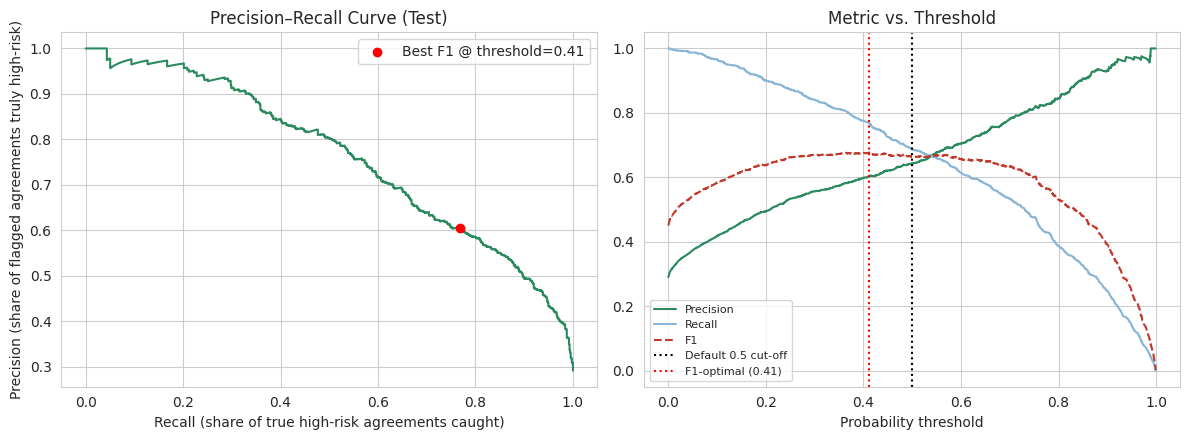

Default threshold 0.50 -> Precision 0.643, Recall 0.687
F1-optimal threshold 0.41 -> Precision 0.605, Recall 0.769

Business note: in residual-risk scoring, missing a genuinely high-risk agreement (a False
Negative) is usually costlier than over-flagging one for review (a False Positive) — so
underwriting may deliberately prefer a LOWER threshold than the F1-optimal one to raise Recall,
accepting more manual reviews in exchange for catching more true shortfalls.


In [33]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(yc_test, proba_test)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.nanargmax(f1s[:-1])
best_threshold = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(recalls, precisions, color='#2c8a5f')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5,
                label=f'Best F1 @ threshold={best_threshold:.2f}')
axes[0].set_xlabel('Recall (share of true high-risk agreements caught)')
axes[0].set_ylabel('Precision (share of flagged agreements truly high-risk)')
axes[0].set_title('Precision–Recall Curve (Test)'); axes[0].legend()

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='#2c8a5f')
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='#8ab6d6')
axes[1].plot(thresholds, f1s[:-1], label='F1', color='#c0392b', ls='--')
axes[1].axvline(0.5, color='k', ls=':', label='Default 0.5 cut-off')
axes[1].axvline(best_threshold, color='red', ls=':', label=f'F1-optimal ({best_threshold:.2f})')
axes[1].set_xlabel('Probability threshold'); axes[1].set_title('Metric vs. Threshold')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f'Default threshold 0.50 -> Precision {precision_score(yc_test,(proba_test>=0.5).astype(int)):.3f}, '
      f'Recall {recall_score(yc_test,(proba_test>=0.5).astype(int)):.3f}')
print(f'F1-optimal threshold {best_threshold:.2f} -> Precision {precisions[best_idx]:.3f}, Recall {recalls[best_idx]:.3f}')
print('\nBusiness note: in residual-risk scoring, missing a genuinely high-risk agreement (a False')
print('Negative) is usually costlier than over-flagging one for review (a False Positive) — so')
print('underwriting may deliberately prefer a LOWER threshold than the F1-optimal one to raise Recall,')
print('accepting more manual reviews in exchange for catching more true shortfalls.')


### 9.6 Out-of-Time Validation — Does the Model Hold Up on Genuinely Future Agreements?

Random K-fold and the random 80/20 splits used so far can mix agreements from across 2018–2026 into
both Train and Test, which **overstates** real-world performance for a market that is actively
shifting (EV adoption, inflation, used-vehicle pricing). A stricter, more realistic check trains on the
**earliest** agreements and tests on the **most recent** ones — exactly the regime the model will
face in production.

In [34]:
df_time = df.sort_values('Agmt_Date').reset_index(drop=True)
cut = int(len(df_time) * 0.8)

# Regression — out-of-time
Xr_oot_train, yr_oot_train = df_time.loc[:cut-1, reg_num+reg_cat], df_time.loc[:cut-1, REG_TARGET]
Xr_oot_test,  yr_oot_test  = df_time.loc[cut:,   reg_num+reg_cat], df_time.loc[cut:,   REG_TARGET]
reg_oot_pipe = Pipeline([('pre', pre_reg), ('model', reg_models['XGBoost'])]).fit(Xr_oot_train, yr_oot_train)

print('REGRESSION — Random split Test RMSE:', f"{overfit_reg.loc['Test','RMSE']:,.0f}",
      '   Out-of-time Test RMSE:', f"{full_metrics_reg(reg_oot_pipe, Xr_oot_test, yr_oot_test)['RMSE']:,.0f}")

# Classification — out-of-time
Xc_oot_train, yc_oot_train = df_time.loc[:cut-1, clf_num+clf_cat], df_time.loc[:cut-1, CLF_TARGET]
Xc_oot_test,  yc_oot_test  = df_time.loc[cut:,   clf_num+clf_cat], df_time.loc[cut:,   CLF_TARGET]
clf_oot_pipe = Pipeline([('pre', pre_clf), ('model', clf_models['XGBoost'])]).fit(Xc_oot_train, yc_oot_train)

print('CLASSIFICATION — Random split Test AUC:', f"{overfit_clf.loc['Test','AUC']:.3f}",
      '   Out-of-time Test AUC:', f"{full_metrics_clf(clf_oot_pipe, Xc_oot_test, yc_oot_test)['AUC']:.3f}")


REGRESSION — Random split Test RMSE: 8,352    Out-of-time Test RMSE: 9,724
CLASSIFICATION — Random split Test AUC: 0.873    Out-of-time Test AUC: 0.822


If the out-of-time metrics are noticeably worse than the random-split metrics, that gap **is**
the model's true exposure to market drift — the honest number to quote to the business, and the
trigger for a periodic retraining / monitoring cadence rather than a one-off model build.